# Escoragem

## Imports

In [1]:
# --- BIBLIOTECAS DE SUPORTE E MANIPULAÇÃO ---
import numpy as np                 # Operações matemáticas e manipulação de arrays/matrizes
import pandas as pd                # Manipulação, limpeza e análise de dados tabulares
import matplotlib.pyplot as plt    # Visualização de dados
import re                          # Expressões regulares para limpeza e padronização de strings
import unicodedata                 # Normalização de caracteres e remoção de acentuação
import joblib                      # Para carregar o modelo salvo
from scipy.stats import ks_2samp   # Funções de estatística avançada e detecção de outliers

# --- CONFIGURAÇÕES DO AMBIENTE ---
import warnings
warnings.filterwarnings("ignore")  # Suprime alertas de sistema para manter o output limpo
pd.set_option('display.max_columns', None) # Garante a visualização de todas as colunas do DataFrame

## A - Carregar o modelo criado

In [2]:
modelo_final = joblib.load('versao_2.pkl')

## B - Saneamento do texto

In [3]:
def pre_processar_texto(texto):
    if not isinstance(texto, str):
        return ""
    
    # A. Tudo para minúsculo
    texto = texto.lower()
    
    # B. Remoção de acentos (Normalização Unicode)
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    
    # C. Remoção de caracteres especiais, hifens e pontuação
    # Mantém apenas letras e espaços
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    
    # D. Remoção de espaços extras
    texto = " ".join(texto.split())
    
    return texto

## C - Estatística KS

In [4]:
#Métrica de performance do escore
def calcular_ks_2samp(df, alvo, escore):
    bons_escore = df.loc[df[alvo] == 0, escore].rename('bons')
    maus_escore = df.loc[df[alvo] == 1, escore].rename('maus')
    return ks_2samp(bons_escore, maus_escore).statistic

# 1 - Importação dos dados

In [5]:
#Base de dados
df = pd.read_csv('contestacoes_fronteiras_2026.csv', engine='python', encoding='utf-8', dtype={'inscricao': object}, sep=',', on_bad_lines='skip')
#Visualização
df.head(3)

,registro_nota,contestacao,period_fiscal,ano_fiscal,extempoaneo,inscricao,razao_social,situacao_contrib.,dentro_prazo,status_processo,segmento_economico,regime_contrib.,motivo_contestacao,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,valor_pago,cod_motivo,descricao_motivo
0,012.6.124041024-6,202600000379600300,202605,2026,202106,72159081,M S DOS SANTOS JUNIOR COMERCIO VAREJISTA DE MO...,ATIVO,N,7-ABERTO,017-VAREJO,05-SIMPLES,346-DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-D...,MERCADORIA-FOI-DEVOLVIDA-DE-ACORDO-COM-A-NF-32...,98.96,0.0,46.48,346,DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-DEC.-...
1,012.6.267317481-4,202600000413328043,202605,2026,202406,74858327,AUTO ELETRICA OSLEAN LTDA,ATIVO,N,7-ABERTO,018-VEICULOS,05-SIMPLES,255-MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODU...,ATIVO-FIXO-MAQUINA-PARA-TRABALHAR-ELEVADOR,3076.09,756.0,0.00,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...
2,012.6.268627091-4,202600000413328043,202605,2026,202406,74858327,AUTO ELETRICA OSLEAN LTDA,ATIVO,N,7-ABERTO,018-VEICULOS,05-SIMPLES,255-MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODU...,ATIVO-FIXO-MAQUINAS-PARA-TRABALHAR,685.54,0.0,0.00,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...


In [6]:
#Retificar a inscrição estadual
df['inscricao'] = df['inscricao'].str.replace(r'\.0$', '', regex=True).str.zfill(9)

## Tabela auxiliar dos motivos

In [7]:
motivos = df[['cod_motivo', 'descricao_motivo']].drop_duplicates()
#Volumetria
motivos.shape[0]

79

In [8]:
#Visualização
motivos.head(3)

,cod_motivo,descricao_motivo
0,346,DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-DEC.-...
1,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...
3,214,OUTROS


# 2 - Análise Exploratória dos Dados

**Contestações**

In [9]:
#Volumetria
volumetria = df.shape[0] 
print(f"Volumetria: {volumetria}") #137.147

Volumetria: 137147


In [10]:
#Volumetria por mês: Período Fiscal
vol_safra = df.groupby(['period_fiscal'])['period_fiscal'].count()
vol_safra.head(10)

period_fiscal
202601    39969
202602    36249
202603    44288
202604    16114
202605      527
Name: period_fiscal, dtype: int64

**Inscrições Estaduais**

In [11]:
#Inscrições estaduais distintas
df['inscricao'].nunique() #12.970

12970

In [12]:
#Top 10 - Inscrições Estaduais
##Maiores contestações abertas
df['inscricao'].value_counts().head(10)

inscricao
026561409    933
102036136    793
026008114    700
107520133    700
044858825    654
128864400    574
061207764    568
035126302    524
112505260    515
054144400    511
Name: count, dtype: int64

**Status das contestações**

In [13]:
#Classificação status_processo
df['status_processo'].value_counts()

status_processo
7-ABERTO                    127713
1-DEFERIDO                    3282
2-INDEFERIDO                  2475
9-EM ANDAMENTO                1951
19-DEFERIDO PARCIALMENTE      1726
Name: count, dtype: int64

In [14]:
round(100 * (3282/ (3282+2475)),2) #Taxa de deferimento: 57%

57.01

In [15]:
#Distribuição das contestações por motivo
tabela_analise_0 = df.groupby('cod_motivo').agg(
    total_processos_analisados=('cod_motivo', 'count')
).reset_index()

# Calcular percentual de processos analisados (frequência relativa)
tabela_analise_0['percentual_processos_analisados'] = (tabela_analise_0['total_processos_analisados'] / len(df) * 100).round(2)

# Selecionar apenas as colunas desejadas
tabela_analise_0 = tabela_analise_0[['cod_motivo', 
                                  'total_processos_analisados', 
                                  'percentual_processos_analisados']]

# Ordenar por total de processos (do maior para o menor)
tabela_analise_0 = tabela_analise_0.sort_values('total_processos_analisados', ascending=False).reset_index(drop=True)

#Visualização
tabela_analise_0.head(10)

,cod_motivo,total_processos_analisados,percentual_processos_analisados
0,214,50090,36.52
1,232,25218,18.39
2,209,5852,4.27
3,346,5481,4.00
4,250,5192,3.79
5,359,5055,3.69
6,238,4402,3.21
7,228,3238,2.36
8,343,2244,1.64
9,248,2069,1.51


In [16]:
left_join = pd.merge(tabela_analise_0, motivos, on = ['cod_motivo'], how='left')
#Visualização
left_join.head(10)

,cod_motivo,total_processos_analisados,percentual_processos_analisados,descricao_motivo
0,214,50090,36.52,OUTROS
1,232,25218,18.39,USO -CONSUMO-E-ATIVO-FIXO
2,209,5852,4.27,AUTOPECAS -ARTS-99-A-101 -ANEXO-37 -DECRETO-44...
3,346,5481,4.00,DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-DEC.-...
4,250,5192,3.79,DANFE-CANCELADO-PELO-EMITENTE
5,359,5055,3.69,SIMPLES-NACIONAL-SEM-REDUCAO-DE-BASE-DE-CALCUL...
6,238,4402,3.21,PRODUTO-DE-SUBSTITUICAO-PAGO-POR-GNRE---ART-12...
7,228,3238,2.36,ISENCAO---ANEXO-7-DO-DECRETO-44.650/2017
8,343,2244,1.64,CONVENIO-01/99---ISENCAO-PRODUTOS-HOSPITALARES...
9,248,2069,1.51,REMESSA-POR-CONTA-E-ORDEM-DE-TERCEIROS


**Visão financeira**

In [17]:
df['valor_cobrado'].sum() #447.712.981,72

np.float64(447712981.72)

In [18]:
df['valor_sugerido_contrib'].sum() #125.214.083,74000001

np.float64(125214083.74000001)

In [19]:
#Delta
df['valor_cobrado'].sum() - df['valor_sugerido_contrib'].sum() #322.498.897,98

np.float64(322498897.98)

# 3 - Variáveis necessárias para a modelagem

1. **Variáveis Contínuas** 
2. **Flags Binárias** 
3. **Variáveis de Texto** 

## Variáveis contínuas

In [20]:
#Variáveis numéricas
##Variável delta financeiro
df['delta_financeiro'] = df['valor_cobrado'].fillna(0) - df['valor_sugerido_contrib'].fillna(0)
##Variável total de palavras
###df['total_palavras'] = df['procontenf_tx_justificativa'].fillna("").apply(lambda x: len(str(x).split()))
# Contar caracteres excluindo hífens --foi aplicado pois o texto bruto trocou o espaço por traço (adaptação)
# Substituir hífen por espaço e depois contar palavras
df['total_palavras'] = (df['procontenf_tx_justificativa']
                        .fillna("")
                        .astype(str)
                        .str.replace('-', ' ')  # Substitui hífen por espaço
                        .str.split()            # Divide em palavras
                        .str.len())             # Conta palavras

In [22]:
#Distribuição das palavras por justificativa
df['total_palavras'].describe()

count    137147.000000
mean         31.806930
std          49.290635
min           0.000000
25%           7.000000
50%          16.000000
75%          36.000000
max         513.000000
Name: total_palavras, dtype: float64

## Variáveis flag

In [21]:
#Variáveis flag
##código de motivo
df['flag_cd_214'] = np.where(df['cod_motivo'] == 214, 1,0)
df['flag_cd_232'] = np.where(df['cod_motivo'] == 232, 1,0)
df['flag_cd_taxa_alta'] = df['cod_motivo'].isin([228, 346, 343, 272, 211]).astype(int)
df['flag_cd_taxa_baixa'] = np.where(df['cod_motivo'] == 265, 1,0)
##delta financeiro
df['flag_df_positivo'] = np.where(df['delta_financeiro']>0, 1, 0)
##regime de contribuição
df['flag_rc_simples'] = np.where(df['regime_contrib.'] == '05-SIMPLES', 1,0)
##segmento econômico
df['flag_se_taxa_alta'] = np.where((df['segmento_economico'] == '018-VEICULOS') | (df['segmento_economico'] == '012-SUPERMERCADOS'), 1, 0)
df['flag_se_taxa_baixa'] = np.where(df['segmento_economico'] == '013-TECIDOS', 1,0)
##valor cobrado
df['flag_vc_ate_100'] = np.where(df['valor_cobrado']<=100, 1, 0)

## Variáveis de texto

In [24]:
#Variável de texto
df['flag_justificativa_ausente'] = df['procontenf_tx_justificativa'].isna().astype(int) #Indica se o contribuiente escreveu algo no campo da justificativa
df['justificativa_limpa'] = df['procontenf_tx_justificativa'].fillna('sem_justificativa_informada').apply(pre_processar_texto) #Feature Textual Principal

In [25]:
df['flag_justificativa_ausente'].value_counts(True) #8% das contestações não apresentaram justificativa

flag_justificativa_ausente
0    0.92045
1    0.07955
Name: proportion, dtype: float64

### Consolidação dos resultados

In [26]:
#Data frame com as variáveis adicionais
df.head(3)

,registro_nota,contestacao,period_fiscal,ano_fiscal,extempoaneo,inscricao,razao_social,situacao_contrib.,dentro_prazo,status_processo,segmento_economico,regime_contrib.,motivo_contestacao,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,valor_pago,cod_motivo,descricao_motivo,delta_financeiro,total_palavras,flag_cd_214,flag_cd_232,flag_cd_taxa_alta,flag_cd_taxa_baixa,flag_df_positivo,flag_rc_simples,flag_se_taxa_alta,flag_se_taxa_baixa,flag_vc_ate_100,flag_justificativa_ausente,justificativa_limpa
0,012.6.124041024-6,202600000379600300,202605,2026,202106,072159081,M S DOS SANTOS JUNIOR COMERCIO VAREJISTA DE MO...,ATIVO,N,7-ABERTO,017-VAREJO,05-SIMPLES,346-DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-D...,MERCADORIA-FOI-DEVOLVIDA-DE-ACORDO-COM-A-NF-32...,98.96,0.0,46.48,346,DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-DEC.-...,98.96,24,0,0,1,0,1,1,0,0,1,0,mercadoria foi devolvida de acordo com a nf em...
1,012.6.267317481-4,202600000413328043,202605,2026,202406,074858327,AUTO ELETRICA OSLEAN LTDA,ATIVO,N,7-ABERTO,018-VEICULOS,05-SIMPLES,255-MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODU...,ATIVO-FIXO-MAQUINA-PARA-TRABALHAR-ELEVADOR,3076.09,756.0,0.00,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...,2320.09,6,0,0,0,0,1,1,1,0,0,0,ativo fixo maquina para trabalhar elevador
2,012.6.268627091-4,202600000413328043,202605,2026,202406,074858327,AUTO ELETRICA OSLEAN LTDA,ATIVO,N,7-ABERTO,018-VEICULOS,05-SIMPLES,255-MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODU...,ATIVO-FIXO-MAQUINAS-PARA-TRABALHAR,685.54,0.0,0.00,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...,685.54,5,0,0,0,0,1,1,1,0,0,0,ativo fixo maquinas para trabalhar


# 4 - Escoragem

In [27]:
df['escore_procedencia'] = modelo_final.predict_proba(df)[:, 1]

## Aplicar o Rating 

In [28]:
condicoes = [
        (df['escore_procedencia'] <= 0.02),
        (df['escore_procedencia'] > 0.02) & (df['escore_procedencia'] <= 0.9),
        (df['escore_procedencia'] > 0.9)
    ]
categorias = ['contestacao_indeferida', 'contestacao_para_analise', 'contestacao_deferida']
df['rating'] = np.select(condicoes, categorias, default='erro_no_escore')

In [29]:
#Distribuição do rating
df['rating'].value_counts()

rating
contestacao_para_analise    56231
contestacao_deferida        44293
contestacao_indeferida      36623
Name: count, dtype: int64

In [30]:
#Visualização
df.head(3)

,registro_nota,contestacao,period_fiscal,ano_fiscal,extempoaneo,inscricao,razao_social,situacao_contrib.,dentro_prazo,status_processo,segmento_economico,regime_contrib.,motivo_contestacao,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,valor_pago,cod_motivo,descricao_motivo,delta_financeiro,total_palavras,flag_cd_214,flag_cd_232,flag_cd_taxa_alta,flag_cd_taxa_baixa,flag_df_positivo,flag_rc_simples,flag_se_taxa_alta,flag_se_taxa_baixa,flag_vc_ate_100,flag_justificativa_ausente,justificativa_limpa,escore_procedencia,rating
0,012.6.124041024-6,202600000379600300,202605,2026,202106,072159081,M S DOS SANTOS JUNIOR COMERCIO VAREJISTA DE MO...,ATIVO,N,7-ABERTO,017-VAREJO,05-SIMPLES,346-DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-D...,MERCADORIA-FOI-DEVOLVIDA-DE-ACORDO-COM-A-NF-32...,98.96,0.0,46.48,346,DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-DEC.-...,98.96,24,0,0,1,0,1,1,0,0,1,0,mercadoria foi devolvida de acordo com a nf em...,0.279543,contestacao_para_analise
1,012.6.267317481-4,202600000413328043,202605,2026,202406,074858327,AUTO ELETRICA OSLEAN LTDA,ATIVO,N,7-ABERTO,018-VEICULOS,05-SIMPLES,255-MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODU...,ATIVO-FIXO-MAQUINA-PARA-TRABALHAR-ELEVADOR,3076.09,756.0,0.00,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...,2320.09,6,0,0,0,0,1,1,1,0,0,0,ativo fixo maquina para trabalhar elevador,0.699477,contestacao_para_analise
2,012.6.268627091-4,202600000413328043,202605,2026,202406,074858327,AUTO ELETRICA OSLEAN LTDA,ATIVO,N,7-ABERTO,018-VEICULOS,05-SIMPLES,255-MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODU...,ATIVO-FIXO-MAQUINAS-PARA-TRABALHAR,685.54,0.0,0.00,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...,685.54,5,0,0,0,0,1,1,1,0,0,0,ativo fixo maquinas para trabalhar,0.198399,contestacao_para_analise


In [31]:
#Base completa
df_full = df[['registro_nota', 'contestacao', 'period_fiscal', 'ano_fiscal', 'extempoaneo', 'inscricao',
             'razao_social', 'segmento_economico', 'regime_contrib.', 'situacao_contrib.','dentro_prazo',
             'cod_motivo', 'descricao_motivo', 'procontenf_tx_justificativa', 'valor_cobrado',
              'valor_sugerido_contrib', 'delta_financeiro','valor_pago','escore_procedencia',
             'rating', 'status_processo']]
#Salvar
df_full.to_excel('base_completa_modelo.xlsx', index=False)

In [32]:
#Visualização
df_full.head(3)

,registro_nota,contestacao,period_fiscal,ano_fiscal,extempoaneo,inscricao,razao_social,segmento_economico,regime_contrib.,situacao_contrib.,dentro_prazo,cod_motivo,descricao_motivo,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,delta_financeiro,valor_pago,escore_procedencia,rating,status_processo
0,012.6.124041024-6,202600000379600300,202605,2026,202106,072159081,M S DOS SANTOS JUNIOR COMERCIO VAREJISTA DE MO...,017-VAREJO,05-SIMPLES,ATIVO,N,346,DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-DEC.-...,MERCADORIA-FOI-DEVOLVIDA-DE-ACORDO-COM-A-NF-32...,98.96,0.0,98.96,46.48,0.279543,contestacao_para_analise,7-ABERTO
1,012.6.267317481-4,202600000413328043,202605,2026,202406,074858327,AUTO ELETRICA OSLEAN LTDA,018-VEICULOS,05-SIMPLES,ATIVO,N,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...,ATIVO-FIXO-MAQUINA-PARA-TRABALHAR-ELEVADOR,3076.09,756.0,2320.09,0.00,0.699477,contestacao_para_analise,7-ABERTO
2,012.6.268627091-4,202600000413328043,202605,2026,202406,074858327,AUTO ELETRICA OSLEAN LTDA,018-VEICULOS,05-SIMPLES,ATIVO,N,255,MAQUINA -APARELHO-E-EQUIP.-INDUST.-E-PRODUTOR ...,ATIVO-FIXO-MAQUINAS-PARA-TRABALHAR,685.54,0.0,685.54,0.00,0.198399,contestacao_para_analise,7-ABERTO


# 5 - Avaliação da performance do modelo

* Contestações julgadas: **deferidas** e **indeferidas**

## Construção da base

In [33]:
df_resultado = df.loc[(df.status_processo == '1-DEFERIDO') | (df.status_processo == '2-INDEFERIDO')]
#Volumetria
df_resultado.shape[0] #5757

5757

**Criação da variável resultado (se foi deferido 1 ou não 0)**

In [34]:
#Variável alvo
df_resultado['resultado'] = np.where(df_resultado['status_processo'] == '1-DEFERIDO', 1, 0)

**Visão deferimento vs motivo**

In [35]:
# Criar tabela com as colunas solicitadas
tabela_analise_2 = df_resultado.groupby('cod_motivo').agg(
    total_processos_analisados=('cod_motivo', 'count'),
    total_deferidos=('resultado', 'sum')
).reset_index()

# Calcular percentual de processos analisados (frequência relativa)
tabela_analise_2['percentual_processos_analisados'] = (tabela_analise_2['total_processos_analisados'] / len(df_resultado) * 100).round(2)

# Calcular taxa de deferimento
tabela_analise_2['taxa_deferimento'] = (tabela_analise_2['total_deferidos'] / tabela_analise_2['total_processos_analisados'] * 100).round(2)

# Selecionar apenas as colunas desejadas
tabela_analise_2 = tabela_analise_2[['cod_motivo', 
                                  'total_processos_analisados', 
                                  'percentual_processos_analisados', 
                                  'taxa_deferimento']]

# Ordenar por total de processos (do maior para o menor)
tabela_analise_2 = tabela_analise_2.sort_values('total_processos_analisados', ascending=False).reset_index(drop=True)

#Visualização
tabela_analise_2.head(10)

,cod_motivo,total_processos_analisados,percentual_processos_analisados,taxa_deferimento
0,214,2124,36.89,54.33
1,265,644,11.19,0.00
2,232,624,10.84,88.30
3,238,545,9.47,14.68
4,186,202,3.51,94.06
5,250,191,3.32,91.10
6,211,177,3.07,100.00
7,346,172,2.99,84.88
8,209,171,2.97,94.15
9,359,91,1.58,34.07


In [36]:
left_join_2 = pd.merge(tabela_analise_2, motivos, on = ['cod_motivo'], how='left')
#Visualização
left_join_2.head(10)

,cod_motivo,total_processos_analisados,percentual_processos_analisados,taxa_deferimento,descricao_motivo
0,214,2124,36.89,54.33,OUTROS
1,265,644,11.19,0.00,REMESSA-EM-GARANTIA -CONVENIO-129/2006-E-27/2007
2,232,624,10.84,88.30,USO -CONSUMO-E-ATIVO-FIXO
3,238,545,9.47,14.68,PRODUTO-DE-SUBSTITUICAO-PAGO-POR-GNRE---ART-12...
4,186,202,3.51,94.06,CIMENTO- -ARTS.-41-E-42 -ANEXO-37 -DECRETO-44....
5,250,191,3.32,91.10,DANFE-CANCELADO-PELO-EMITENTE
6,211,177,3.07,100.00,AGUA-MINERAL----ART.-62-E-63 -ANEXO-37 -DECRET...
7,346,172,2.99,84.88,DEVOLUCAO-DE-MERCADORIA---ART.-529-A-536-DEC.-...
8,209,171,2.97,94.15,AUTOPECAS -ARTS-99-A-101 -ANEXO-37 -DECRETO-44...
9,359,91,1.58,34.07,SIMPLES-NACIONAL-SEM-REDUCAO-DE-BASE-DE-CALCUL...


**Visão deferimento vs delta financeiro**

In [37]:
# Criar tabela com as colunas solicitadas
tabela_analise_3 = df_resultado.groupby('flag_df_positivo').agg(
    total_processos_analisados=('flag_df_positivo', 'count'),
    total_deferidos=('resultado', 'sum')
).reset_index()

# Calcular percentual de processos analisados (frequência relativa)
tabela_analise_3['percentual_processos_analisados'] = (tabela_analise_3['total_processos_analisados'] / len(df_resultado) * 100).round(2)

# Calcular taxa de deferimento
tabela_analise_3['taxa_deferimento'] = (tabela_analise_3['total_deferidos'] / tabela_analise_3['total_processos_analisados'] * 100).round(2)

# Selecionar apenas as colunas desejadas
tabela_analise_3 = tabela_analise_3[['flag_df_positivo', 
                                  'total_processos_analisados', 
                                  'percentual_processos_analisados', 
                                  'taxa_deferimento']]

# Ordenar por total de processos (do maior para o menor)
tabela_analise_3 = tabela_analise_3.sort_values('total_processos_analisados', ascending=False).reset_index(drop=True)

#Visualização
tabela_analise_3.head(10)

,flag_df_positivo,total_processos_analisados,percentual_processos_analisados,taxa_deferimento
0,1,3292,57.18,26.88
1,0,2465,42.82,97.24


## Performance do modelo

In [38]:
#Distribuição do rating
df_resultado['rating'].value_counts()

rating
contestacao_deferida        2895
contestacao_indeferida      1483
contestacao_para_analise    1379
Name: count, dtype: int64

In [39]:
#Esatística KS
calcular_ks_2samp(df_resultado, 'resultado', 'escore_procedencia') #73

np.float64(0.7276202611120344)

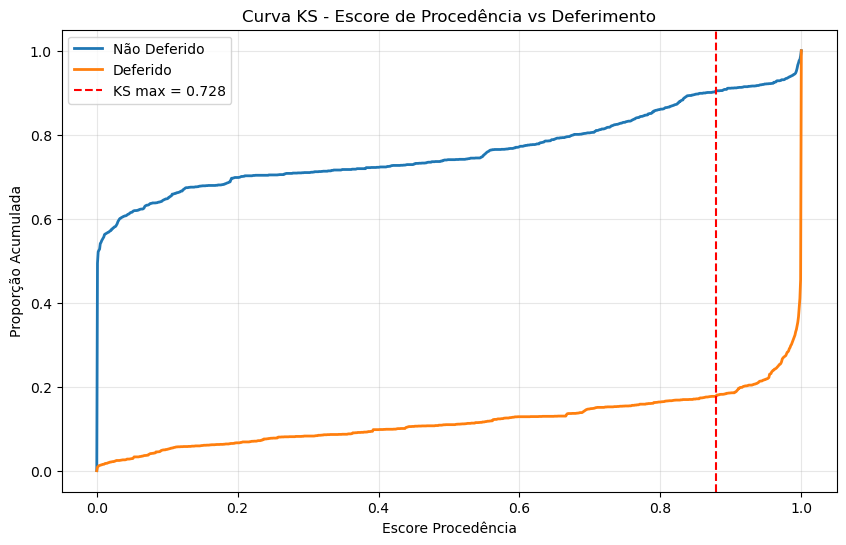

KS máximo: 0.7276 no ponto 0.8789


In [40]:
#Gráfico do KS

# Preparar dados
escore_0 = df_resultado[df_resultado['resultado'] == 0]['escore_procedencia'].dropna()
escore_1 = df_resultado[df_resultado['resultado'] == 1]['escore_procedencia'].dropna()

# Criar grade de valores
x = np.linspace(df_resultado['escore_procedencia'].min(), 
                df_resultado['escore_procedencia'].max(), 1000)

# Calcular ECDFs
y0 = np.array([np.mean(escore_0 <= xi) for xi in x])
y1 = np.array([np.mean(escore_1 <= xi) for xi in x])

# KS máximo
ks_stat = np.max(np.abs(y1 - y0))
ks_idx = np.argmax(np.abs(y1 - y0))
ks_point = x[ks_idx]

# Plotar
plt.figure(figsize=(10, 6))
plt.plot(x, y0, label='Não Deferido', linewidth=2)
plt.plot(x, y1, label='Deferido', linewidth=2)
plt.axvline(x=ks_point, color='red', linestyle='--', label=f'KS max = {ks_stat:.3f}')
plt.xlabel('Escore Procedência')
plt.ylabel('Proporção Acumulada')
plt.title('Curva KS - Escore de Procedência vs Deferimento')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"KS máximo: {ks_stat:.4f} no ponto {ks_point:.4f}")

In [41]:
#Distribuição dos escores
with pd.option_context('display.float_format', '{:.10f}'.format):
    print(df_resultado['escore_procedencia'].describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]))

count   5757.0000000000
mean       0.6049852556
std        0.4441648454
min        0.0000000000
10%        0.0000023388
20%        0.0003811574
30%        0.0861269686
40%        0.5770083979
50%        0.9079581485
60%        0.9927987420
70%        0.9992320312
80%        0.9998867879
90%        0.9999906760
max        0.9999999998
Name: escore_procedencia, dtype: float64


**Taxa de deferimento vs range de escore**

In [42]:
# Criar as faixas de escore
bins = [0, 0.1, 0.9, 1.0]
labels = ['0 - 0.1', '0.1 - 0.9', '0.9 - 1.0']

# Criar a coluna de faixa
df_resultado['faixa_escore'] = pd.cut(df_resultado['escore_procedencia'], 
                                      bins=bins, 
                                      labels=labels, 
                                      include_lowest=True, 
                                      right=False)

# Calcular as métricas por faixa
tabela_escore = df_resultado.groupby('faixa_escore').agg(
    volumetria=('escore_procedencia', 'count'),
    total_resultado=('resultado', 'sum')
).reset_index()

# Calcular volumetria percentual
total_geral = len(df_resultado)
tabela_escore['volumetria_percentual'] = (tabela_escore['volumetria'] / total_geral * 100).round(2)

# Calcular taxa de resultado
tabela_escore['taxa_resultado'] = (tabela_escore['total_resultado'] / tabela_escore['volumetria'] * 100).round(2)

# Selecionar as colunas finais
tabela_escore = tabela_escore[['faixa_escore', 'volumetria', 'volumetria_percentual', 'taxa_resultado']]

print("📊 TAXA DE RESULTADO POR FAIXA DE ESCORE")
print("="*60)
print(tabela_escore.to_string(index=False))

# Adicionar linha de total (opcional)
total_linha = pd.DataFrame({
    'faixa_escore': ['TOTAL'],
    'volumetria': [tabela_escore['volumetria'].sum()],
    'volumetria_percentual': [100.0],
    'taxa_resultado': [(df_resultado['resultado'].sum() / len(df_resultado) * 100).round(2)]
})

tabela_com_total = pd.concat([tabela_escore, total_linha], ignore_index=True)

print("\n📊 TABELA COM TOTAL")
print("="*60)
print(tabela_com_total.to_string(index=False))

📊 TAXA DE RESULTADO POR FAIXA DE ESCORE
faixa_escore  volumetria  volumetria_percentual  taxa_resultado
     0 - 0.1        1770                  30.75            9.44
   0.1 - 0.9        1092                  18.97           40.38
   0.9 - 1.0        2895                  50.29           92.37

📊 TABELA COM TOTAL
faixa_escore  volumetria  volumetria_percentual  taxa_resultado
     0 - 0.1        1770                  30.75            9.44
   0.1 - 0.9        1092                  18.97           40.38
   0.9 - 1.0        2895                  50.29           92.37
       TOTAL        5757                 100.00           57.01


**Histograma**

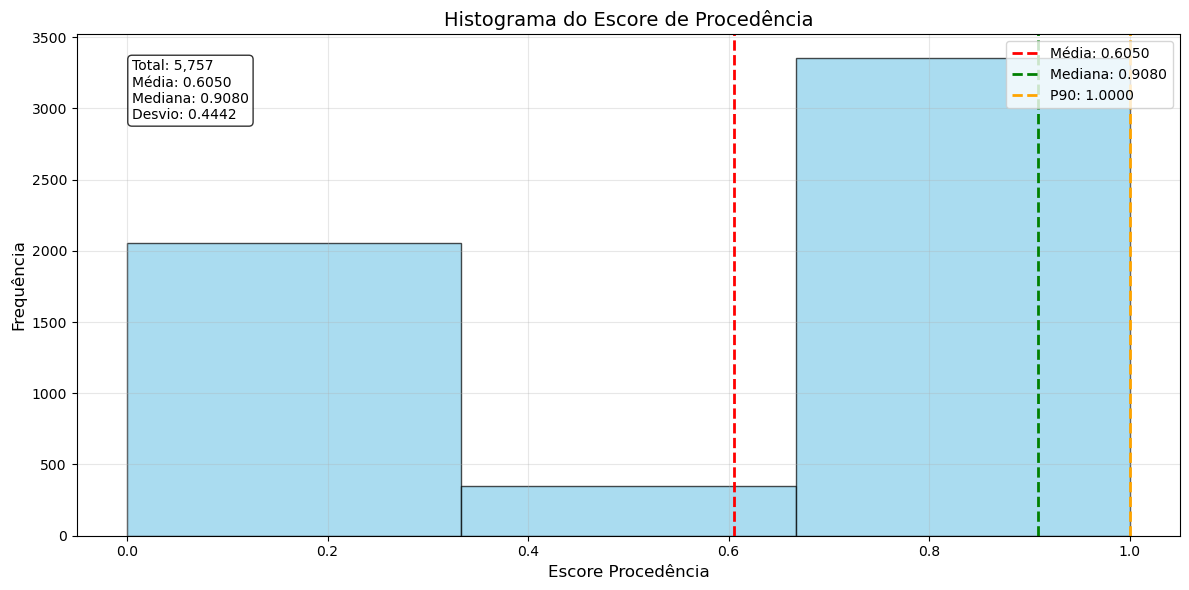

In [43]:
# Calcular estatísticas
escore = df_resultado['escore_procedencia'].dropna()
media = escore.mean()
mediana = escore.median()
percentil_90 = escore.quantile(0.90)

plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(escore, bins=3, color='skyblue', edgecolor='black', alpha=0.7)

# Adicionar linhas verticais
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.4f}')
plt.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.4f}')
plt.axvline(percentil_90, color='orange', linestyle='--', linewidth=2, label=f'P90: {percentil_90:.4f}')

plt.xlabel('Escore Procedência', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title('Histograma do Escore de Procedência', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Adicionar texto com estatísticas
plt.text(0.05, 0.95, f'Total: {len(escore):,}\nMédia: {media:.4f}\nMediana: {mediana:.4f}\nDesvio: {escore.std():.4f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

**Deferido**

In [44]:
deferido_modelo = df_resultado.loc[df_resultado.rating == 'contestacao_deferida']
#Volumetria
deferido_modelo.shape[0] #2.895

2895

In [45]:
deferido_modelo['status_processo'].value_counts() #2.674 acertou

status_processo
1-DEFERIDO      2674
2-INDEFERIDO     221
Name: count, dtype: int64

In [46]:
#Acertividade do modelo
round(100 * deferido_modelo['status_processo'].value_counts(True),2) #Acertei em 93% dos casos

status_processo
1-DEFERIDO      92.37
2-INDEFERIDO     7.63
Name: proportion, dtype: float64

**Indeferido**

In [47]:
indeferido_modelo = df_resultado.loc[df_resultado.rating == 'contestacao_indeferida']
#Volumetria
indeferido_modelo.shape[0] #1483

1483

In [48]:
indeferido_modelo['status_processo'].value_counts() #1.415 acertou

status_processo
2-INDEFERIDO    1415
1-DEFERIDO        68
Name: count, dtype: int64

### Áreas de interesse

**uso e consumo**

In [49]:
deferido_uso_consumo = deferido_modelo.loc[deferido_modelo.cod_motivo == 232]
#Visualização
deferido_uso_consumo.head(3)

,registro_nota,contestacao,period_fiscal,ano_fiscal,extempoaneo,inscricao,razao_social,situacao_contrib.,dentro_prazo,status_processo,segmento_economico,regime_contrib.,motivo_contestacao,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,valor_pago,cod_motivo,descricao_motivo,delta_financeiro,total_palavras,flag_cd_214,flag_cd_232,flag_cd_taxa_alta,flag_cd_taxa_baixa,flag_df_positivo,flag_rc_simples,flag_se_taxa_alta,flag_se_taxa_baixa,flag_vc_ate_100,flag_justificativa_ausente,justificativa_limpa,escore_procedencia,rating,resultado,faixa_escore
958,012.6.437452280-9,202600000295771775,202604,2026,202601,033339570,BEIRA RIO REVENDA DE BEBIDAS LTDA,ATIVO,N,1-DEFERIDO,003-BEBIDAS,01-NORMAL,232-USO -CONSUMO-E-ATIVO-FIXO,ALGUNS-PRODUTOS-ESTA-SENDO-CONSIDERADO-PARA-RE...,46.54,46.54,46.54,232,USO -CONSUMO-E-ATIVO-FIXO,0.00,47,0,1,0,0,0,0,0,0,1,0,alguns produtos esta sendo considerado para re...,0.999715,contestacao_deferida,1,0.9 - 1.0
961,012.6.437546979-0,202600000295771775,202604,2026,202601,033339570,BEIRA RIO REVENDA DE BEBIDAS LTDA,ATIVO,N,1-DEFERIDO,003-BEBIDAS,01-NORMAL,232-USO -CONSUMO-E-ATIVO-FIXO,ALGUNS-PRODUTOS-ESTA-SENDO-CONSIDERADO-PARA-RE...,82.21,67.27,82.21,232,USO -CONSUMO-E-ATIVO-FIXO,14.94,43,0,1,0,0,1,0,0,0,1,0,alguns produtos esta sendo considerado para re...,0.996546,contestacao_deferida,1,0.9 - 1.0
965,012.6.437768886-4,202600000295771775,202604,2026,202601,033339570,BEIRA RIO REVENDA DE BEBIDAS LTDA,ATIVO,N,1-DEFERIDO,003-BEBIDAS,01-NORMAL,232-USO -CONSUMO-E-ATIVO-FIXO,ALGUNS-PRODUTOS-ESTA-SENDO-CONSIDERADO-PARA-RE...,13.42,13.42,13.42,232,USO -CONSUMO-E-ATIVO-FIXO,0.00,43,0,1,0,0,0,0,0,0,1,0,alguns produtos esta sendo considerado para re...,0.999741,contestacao_deferida,1,0.9 - 1.0


In [50]:
deferido_uso_consumo.shape[0]

536

In [51]:
#Acertividade do modelo
deferido_uso_consumo['status_processo'].value_counts() #Acertou 486

status_processo
1-DEFERIDO      486
2-INDEFERIDO     50
Name: count, dtype: int64

**Deferido com delta financeiro até 100 reais**

In [52]:
df_deferido_ate100 = df_resultado.loc[(df_resultado.rating == 'contestacao_deferida') & (df_resultado.delta_financeiro <=100)]
#Volumetria
df_deferido_ate100.shape[0] #2639

2639

In [53]:
#Acertividade do modelo
df_deferido_ate100['status_processo'].value_counts()

status_processo
1-DEFERIDO      2558
2-INDEFERIDO      81
Name: count, dtype: int64

In [54]:
2558/2639

0.969306555513452

**Indeferido com delta financeiro mais de 100 reais**

In [55]:
df_indeferido_m100 = df_resultado.loc[(df_resultado.rating == 'contestacao_indeferida') & (df_resultado.delta_financeiro >100)]
#Volumetria
df_indeferido_m100.shape[0] #751

751

In [56]:
#Acertividade do modelo
df_indeferido_m100['status_processo'].value_counts()

status_processo
2-INDEFERIDO    717
1-DEFERIDO       34
Name: count, dtype: int64

# 6 - Exportar os resultados

In [57]:
df_resultado.head(3)

,registro_nota,contestacao,period_fiscal,ano_fiscal,extempoaneo,inscricao,razao_social,situacao_contrib.,dentro_prazo,status_processo,segmento_economico,regime_contrib.,motivo_contestacao,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,valor_pago,cod_motivo,descricao_motivo,delta_financeiro,total_palavras,flag_cd_214,flag_cd_232,flag_cd_taxa_alta,flag_cd_taxa_baixa,flag_df_positivo,flag_rc_simples,flag_se_taxa_alta,flag_se_taxa_baixa,flag_vc_ate_100,flag_justificativa_ausente,justificativa_limpa,escore_procedencia,rating,resultado,faixa_escore
72,012.6.389400329-8,202600000380088480,202605,2026,202509,106592696,RTS RIO S/A,ATIVO,N,1-DEFERIDO,018-VEICULOS,01-NORMAL,276-REMESSA-EM-LOCACAO/COMODATO,CONTESTACAO-DA-ANTECIPACAO-TRIBUTARIA--EXTRATO...,0.0,0.0,0.0,276,REMESSA-EM-LOCACAO/COMODATO,0.0,422,0,0,0,0,0,0,1,0,1,0,contestacao da antecipacao tributaria extrato ...,0.362739,contestacao_para_analise,1,0.1 - 0.9
75,012.6.390621896-5,202600000380088480,202605,2026,202509,106592696,RTS RIO S/A,ATIVO,N,1-DEFERIDO,018-VEICULOS,01-NORMAL,276-REMESSA-EM-LOCACAO/COMODATO,CONTESTACAO-DA-ANTECIPACAO-TRIBUTARIA--EXTRATO...,0.0,0.0,0.0,276,REMESSA-EM-LOCACAO/COMODATO,0.0,422,0,0,0,0,0,0,1,0,1,0,contestacao da antecipacao tributaria extrato ...,0.362739,contestacao_para_analise,1,0.1 - 0.9
76,012.6.394767464-7,202600000380088480,202605,2026,202509,106592696,RTS RIO S/A,ATIVO,N,1-DEFERIDO,018-VEICULOS,01-NORMAL,276-REMESSA-EM-LOCACAO/COMODATO,CONTESTACAO-DA-ANTECIPACAO-TRIBUTARIA--EXTRATO...,0.0,0.0,0.0,276,REMESSA-EM-LOCACAO/COMODATO,0.0,422,0,0,0,0,0,0,1,0,1,0,contestacao da antecipacao tributaria extrato ...,0.362739,contestacao_para_analise,1,0.1 - 0.9


In [58]:
df_resultado_final = df_resultado[['registro_nota', 'contestacao', 'period_fiscal', 'ano_fiscal', 'extempoaneo', 
                                   'inscricao', 'razao_social', 'situacao_contrib.', 
                                  'segmento_economico', 'regime_contrib.', 'dentro_prazo','cod_motivo',
                                  'descricao_motivo', 'procontenf_tx_justificativa', 'valor_cobrado', 'valor_sugerido_contrib', 'delta_financeiro',
                                  'valor_pago', 'status_processo', 'rating', 'escore_procedencia']]
#Visualização
df_resultado_final.head(3)

,registro_nota,contestacao,period_fiscal,ano_fiscal,extempoaneo,inscricao,razao_social,situacao_contrib.,segmento_economico,regime_contrib.,dentro_prazo,cod_motivo,descricao_motivo,procontenf_tx_justificativa,valor_cobrado,valor_sugerido_contrib,delta_financeiro,valor_pago,status_processo,rating,escore_procedencia
72,012.6.389400329-8,202600000380088480,202605,2026,202509,106592696,RTS RIO S/A,ATIVO,018-VEICULOS,01-NORMAL,N,276,REMESSA-EM-LOCACAO/COMODATO,CONTESTACAO-DA-ANTECIPACAO-TRIBUTARIA--EXTRATO...,0.0,0.0,0.0,0.0,1-DEFERIDO,contestacao_para_analise,0.362739
75,012.6.390621896-5,202600000380088480,202605,2026,202509,106592696,RTS RIO S/A,ATIVO,018-VEICULOS,01-NORMAL,N,276,REMESSA-EM-LOCACAO/COMODATO,CONTESTACAO-DA-ANTECIPACAO-TRIBUTARIA--EXTRATO...,0.0,0.0,0.0,0.0,1-DEFERIDO,contestacao_para_analise,0.362739
76,012.6.394767464-7,202600000380088480,202605,2026,202509,106592696,RTS RIO S/A,ATIVO,018-VEICULOS,01-NORMAL,N,276,REMESSA-EM-LOCACAO/COMODATO,CONTESTACAO-DA-ANTECIPACAO-TRIBUTARIA--EXTRATO...,0.0,0.0,0.0,0.0,1-DEFERIDO,contestacao_para_analise,0.362739


In [59]:
#Exportar em CSV
df_resultado_final.to_csv('escoragem_2026_base_julgada.csv', index=False, sep=';', encoding='utf-8-sig')
#Exportar em EXCEL
#Salvar
df_resultado_final.to_excel('escoragem_2026_base_julgada.xlsx', index=False)